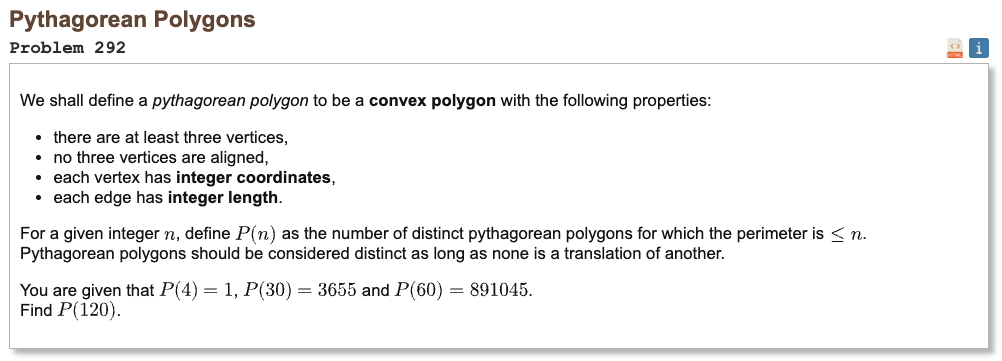

## Initial approach

* Change each polygon into a list of edge directions, then sort them by their angle around the shape.
* Each edge must come from a step with integer length, so only certain directions are allowed, like grid-based directions and Pythagorean ones.
* Split the polygon into a top part and a bottom part, since a convex shape is fixed once these two parts match.
* For each direction, either don’t use it or use one scaled version of it.
* This turns the problem into a kind of limited packing problem with perimeter and position.
* Build a dynamic program for just the top part, keeping track of how many ways you can reach each perimeter and position.
* Then match two top parts that end at the same position, one as the real top and the other as the mirrored bottom.
* Remove the invalid cases where nothing was chosen, and also the simple case of just one segment going out and back.

In [1]:
from math import gcd

def primitive_upper_directions(limit):
    dirs = {(1, 0, 1), (0, 1, 1)}
    m = 2
    while 2 * m * m <= limit:
        for n in range(1, m):
            if ((m - n) & 1) == 0 or gcd(m, n) != 1:
                continue
            a = m * m - n * n
            b = 2 * m * n
            c = m * m + n * n
            if c > limit:
                continue
            x, y = abs(a), abs(b)
            dirs.add((x, y, c))
            dirs.add((y, x, c))
            dirs.add((-x, y, c))
            dirs.add((-y, x, c))
        m += 1
    return sorted(dirs, key=lambda t: (0 if t[1] == 0 else 1, t[0] / (abs(t[1]) + 1e-18), t[2], t[0], t[1]))

def count_polygons(limit):
    directions = primitive_upper_directions(limit)
    dp = [dict() for _ in range(limit + 1)]
    dp[0][(0, 0)] = 1

    for dx, dy, step_len in directions:
        new_dp = [d.copy() for d in dp]
        for p in range(limit + 1):
            if not dp[p]:
                continue
            max_scale = (limit - p) // step_len
            if max_scale == 0:
                continue
            items = list(dp[p].items())
            for (x, y), ways in items:
                for s in range(1, max_scale + 1):
                    np = p + s * step_len
                    key = (x + s * dx, y + s * dy)
                    new_dp[np][key] = new_dp[np].get(key, 0) + ways
        dp = new_dp

    total = 0
    for p1 in range(limit + 1):
        if not dp[p1]:
            continue
        for p2 in range(limit - p1 + 1):
            if not dp[p2]:
                continue
            small = dp[p1] if len(dp[p1]) < len(dp[p2]) else dp[p2]
            large = dp[p2] if small is dp[p1] else dp[p1]
            for key, c1 in small.items():
                c2 = large.get(key)
                if c2:
                    total += c1 * c2

    total -= 1

    degenerate = 0
    for dx, dy, step_len in directions:
        degenerate += limit // (2 * step_len)

    total -= degenerate
    return total

assert count_polygons(4) == 1
assert count_polygons(30) == 3655
assert count_polygons(60) == 891045

In [2]:
%%time
result = count_polygons(120)
print("Result:", result)

Result: 3600060866
CPU times: user 2.78 s, sys: 62.4 ms, total: 2.84 s
Wall time: 2.89 s
